## ToolStrategy是最通用的结构化输出策略
#### 这里又有5种方式： Pydantic，TypeDict，JsonSchema，@dataclass和Union[type1,type2] 这里的type1和type2是同一种方式的2个不同对象


### 1.Pydantic
#### 举例1

In [9]:
from dataclasses import dataclass
from typing import Literal, Annotated, Optional

from langchain_core.messages import SystemMessage
from pydantic import BaseModel, Field
from langchain.agents.structured_output import AutoStrategy
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from rich import print as rprint
# 1.初始化模型
model = ChatOpenAI(
    model="carstenuhlig/omnicoder-9b:latest",
    # model="qwen3-vl:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)
# 2.使用Pydantic结构方式来定义一个类
class ContactInfo(BaseModel):
    """用户的联系方式"""
    name: str = Field(description="用户姓名")
    email: str = Field(description="用户邮箱")
    phone: str = Field(description="用户电话")

# 3.创建agent
agent = create_agent(
    model=model,
    tools=[],
    response_format=AutoStrategy(schema=ContactInfo), # 结构化输出的第3种方式
    system_prompt="Agent的行为指令" # 可选
)
# 3.调用
result = agent.invoke({
    "messages":[{"role":"user","content":"请提取项目文本的用户信息：小李的email是 wxm1234@gmail.com,电话是13532677677"}]
})

rprint(result)






{
    'messages': [
        HumanMessage(
            content='请提取项目文本的用户信息：小李的email是 wxm1234@gmail.com,电话是13532677677',
            additional_kwargs={},
            response_metadata={},
            id='4616422c-67cf-4dd4-89c6-ef0e5312cd24'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 133,
                    'prompt_tokens': 199,
                    'total_tokens': 332,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'carstenuhlig/omnicoder-9b:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-61',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a104be-6381-74a1-989c-2bba41d31b8d-0',
            tool_calls=[
                {
                    'name': 'ContactInfo',
                    'args': {'name': '小李', 'email': 'wxm1234@gmail.com', 'phone': '13532677677'},
                    'id': 'call_jnj4ph10',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 199,
                'output_tokens': 133,
                'total_tokens': 332,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content="Returning structured response: name='小李' email='wxm1234@gmail.com' phone='13532677677'",
            name='ContactInfo',
            id='e4ac4689-d12e-47b8-b945-cb3e84b51eab',
            tool_call_id='call_jnj4ph10'
        )
    ],
    'structured_response': ContactInfo(name='小李', email='wxm1234@gmail.com', phone='13532677677')
}

#### Pydantic举例2

In [10]:
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage
from pydantic import BaseModel, Field
from langchain.agents.structured_output import AutoStrategy, ToolStrategy
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from rich import print as rprint
from typing import Literal

## 1.定义工具
@tool(parse_docstring=True)
def search_customer_database(query: str)->str:
     """
      在客户数据库搜索信息

     Args:
            query: str,客户查询字符串，如："张三" 或 "李四"

     Returns:
            str: 客户记录字符串，包括客户姓名、等级、最近购买日期和累计消费
     """
     if "张三" in query.lower():
          return "客户记录: 张三，VIP客户，最近购买日期：2026-01-15，累计消费：$15,000"
     elif "李四" in query.lower():
          return "客户记录: 李四，普通客户，最近购买日期：2025-12-20，累计消费：$3,200"
     else:
         return f"关于客户{query}，无记录"

@tool(parse_docstring=True)
def send_email(customer: str)->str:
    """
      发送感谢邮件

     Args:
            customer: str,客户名字，如："张三" 或 "李四"

     Returns:
            str: 确认消息，保护已发送的客户名称
     """
    return f"已向客户：{customer}发送感谢邮件"

# 2.初始化模型
model = ChatOpenAI(
    # model="carstenuhlig/omnicoder-9b:latest", # 在这里不好用
    model="qwen3-vl:latest", # ok
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)

# 3.定义Pydantic结构类
class CustomerAnalysis(BaseModel):
    """客户分析报告"""
    customer_name: str = Field(None,description="客户姓名")
    customer_tier: Literal["潜在客户","普通客户","VIP客户","流失风险"] = Field("潜在客户",
                                    description="客户只能是：潜在客户、普通客户、VIP客户和流失风险")
    recent_activity: str = Field(None,description="最近活动")
    spending_level: Literal["低","中","高"] = Field(None,description="消费水平")
    send_email: bool = Field(False,description="是否已发送感谢邮件")


# 4.定义agent
agent = create_agent(
    model=model,
    tools=[search_customer_database,send_email],
    response_format=ToolStrategy(schema=CustomerAnalysis), # 结构化输出的第3种方式
    system_prompt=SystemMessage(content="""
    请分析知道客户的情况:
    1.先搜索客户数据库了解最新情况
    2.如果是VIP客户，则发送感谢邮件
    3.基于搜索结果生成结构化分析报告
    4.如果用户提问与客户记录无关或者找不到客户信息，
    则返回空对象，不发送感谢邮件。
    """)
)
# 3.调用
result = agent.invoke({
    "messages":[{"role":"user","content":"请分析客户张三"}]
})

rprint(result)






{
    'messages': [
        HumanMessage(
            content='请分析客户张三',
            additional_kwargs={},
            response_metadata={},
            id='73fad0b2-253f-458e-9e8b-da8ddbe27557'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 601,
                    'prompt_tokens': 497,
                    'total_tokens': 1098,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 278}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3-vl:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-552',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a104bf-6681-7a30-9c88-913975f31066-0',
            tool_calls=[
                {
                    'name': 'search_customer_database',
                    'args': {'query': '张三'},
                    'id': 'call_hpfmdjlk',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 497,
                'output_tokens': 601,
                'total_tokens': 1098,
                'input_token_details': {'cache_read': 278},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='客户记录: 张三，VIP客户，最近购买日期：2026-01-15，累计消费：$15,000',
            name='search_customer_database',
            id='f264b644-d78c-4265-bfe3-813b6ac8916a',
            tool_call_id='call_hpfmdjlk'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 276,
                    'prompt_tokens': 567,
                    'total_tokens': 843,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 495}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3-vl:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-381',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a104c1-a183-7ab1-9b55-f7bcce347eea-0',
            tool_calls=[
                {'name': 'send_email', 'args': {'customer': '张三'}, 'id': 'call_s6irhf26', 'type': 'tool_call'}
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 567,
                'output_tokens': 276,
                'total_tokens': 843,
                'input_token_details': {'cache_read': 495},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='已向客户：张三发送感谢邮件',
            name='send_email',
            id='33914404-756a-42e8-ac18-d3a11850bf53',
            tool_call_id='call_s6irhf26'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 308,
                    'prompt_tokens': 610,
                    'total_tokens': 918,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 565}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3-vl:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-480',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--

## 2.TypedDict
### 举例1

In [1]:
from typing import TypedDict,Annotated
from langchain.agents.structured_output import AutoStrategy
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from rich import print as rprint
# 1.初始化模型
model = ChatOpenAI(
    model="carstenuhlig/omnicoder-9b:latest",
    # model="qwen3-vl:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)
# 2.使用TypeDict结构方式来定义一个类
class ContactInfo(TypedDict):
    """用户的联系方式"""
    name:  Annotated[str ,...,"用户姓名"]
    email: Annotated[str ,...,"用户邮箱"]
    phone: Annotated[str ,...,"用户电话"]


# 3.创建agent
agent = create_agent(
    model=model,
    tools=[],
    response_format=AutoStrategy(schema=ContactInfo), # 结构化输出的第3种方式
    system_prompt="Agent的行为指令" # 可选
)
# 3.调用
result = agent.invoke({
    "messages":[{"role":"user","content":"请提取项目文本的用户信息：小李的email是 wxm1234@gmail.com,电话是13532677677"}]
})

rprint(result)






{
    'messages': [
        HumanMessage(
            content='请提取项目文本的用户信息：小李的email是 wxm1234@gmail.com,电话是13532677677',
            additional_kwargs={},
            response_metadata={},
            id='b4233fe6-a772-41f9-99ec-d7da209e020f'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 119,
                    'prompt_tokens': 184,
                    'total_tokens': 303,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'carstenuhlig/omnicoder-9b:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-424',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a11361-4dde-7451-80eb-d2e4752c0061-0',
            tool_calls=[
                {
                    'name': 'ContactInfo',
                    'args': {'name': '小李', 'email': 'wxm1234@gmail.com', 'phone': '13532677677'},
                    'id': 'call_tkoum0u8',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 184,
                'output_tokens': 119,
                'total_tokens': 303,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content="Returning structured response: {'name': '小李', 'email': 'wxm1234@gmail.com', 'phone': 
'13532677677'}",
            name='ContactInfo',
            id='09bb261c-2677-492e-8af3-82e705a68b46',
            tool_call_id='call_tkoum0u8'
        )
    ],
    'structured_response': {'name': '小李', 'email': 'wxm1234@gmail.com', 'phone': '13532677677'}
}

### TypeDict举例2

In [2]:
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage
from pydantic import BaseModel, Field
from langchain.agents.structured_output import AutoStrategy, ToolStrategy
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from rich import print as rprint
from typing import Literal,TypedDict,Annotated,Optional

## 1.定义工具
@tool(parse_docstring=True)
def search_customer_database(query: str)->str:
     """
      在客户数据库搜索信息

     Args:
            query: str,客户查询字符串，如："张三" 或 "李四"

     Returns:
            str: 客户记录字符串，包括客户姓名、等级、最近购买日期和累计消费
     """
     if "张三" in query.lower():
          return "客户记录: 张三，VIP客户，最近购买日期：2026-01-15，累计消费：$15,000"
     elif "李四" in query.lower():
          return "客户记录: 李四，普通客户，最近购买日期：2025-12-20，累计消费：$3,200"
     else:
         return f"关于客户{query}，无记录"

@tool(parse_docstring=True)
def send_email(customer: str)->str:
    """
      发送感谢邮件

     Args:
            customer: str,客户名字，如："张三" 或 "李四"

     Returns:
            str: 确认消息，保护已发送的客户名称
     """
    return f"已向客户：{customer}发送感谢邮件"

# 2.初始化模型
model = ChatOpenAI(
    # model="carstenuhlig/omnicoder-9b:latest", # 在这里不好用
    model="qwen3-vl:latest", # ok
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)

# 3.定义TypedDict结构类
class CustomerAnalysis(TypedDict):
    """客户分析报告"""
    customer_name:Annotated[Optional[str],None,"客户姓名"]
    customer_tier:Annotated[Literal["潜在客户","普通客户","VIP客户","流失风险"],"潜在客户","客户等级"]
    recent_activity:Annotated[Optional[str],None,"最近活动"]
    spending_level:Annotated[Optional[Literal["低","中","高"]],None,"消费水平"]
    send_email:Annotated[bool,False,"是否已发送感谢邮件"]

# 4.定义agent
agent = create_agent(
    model=model,
    tools=[search_customer_database,send_email],
    response_format=ToolStrategy(schema=CustomerAnalysis), # 结构化输出的第3种方式
    system_prompt=SystemMessage(content="""
    请分析知道客户的情况:
    1.先搜索客户数据库了解最新情况
    2.如果是VIP客户，则发送感谢邮件
    3.基于搜索结果生成结构化分析报告
    4.如果用户提问与客户记录无关或者找不到客户信息，
    则返回空对象，不发送感谢邮件。
    """)
)
# 3.调用
result = agent.invoke({
    # "messages":[{"role":"user","content":"请分析客户张三"}]
    "messages":[{"role":"user","content":"请分析客户李四"}]
})

rprint(result)






{
    'messages': [
        HumanMessage(
            content='请分析客户李四',
            additional_kwargs={},
            response_metadata={},
            id='741ac08d-0a3f-4bc7-a5d6-fffb1c3d61ae'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 289,
                    'prompt_tokens': 504,
                    'total_tokens': 793,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3-vl:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-168',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a1136e-8ecf-7593-82d4-cdf86ad482c2-0',
            tool_calls=[
                {
                    'name': 'search_customer_database',
                    'args': {'query': '李四'},
                    'id': 'call_s4dma6ug',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 504,
                'output_tokens': 289,
                'total_tokens': 793,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='客户记录: 李四，普通客户，最近购买日期：2025-12-20，累计消费：$3,200',
            name='search_customer_database',
            id='30994185-ba79-45aa-ad4e-43fa4b820d32',
            tool_call_id='call_s4dma6ug'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 506,
                    'prompt_tokens': 573,
                    'total_tokens': 1079,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3-vl:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-709',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a11370-2f4c-7c50-af2f-ad65cf88595c-0',
            tool_calls=[
                {
                    'name': 'CustomerAnalysis',
                    'args': {
                        'customer_name': '李四',
                        'customer_tier': '普通客户',
                        'recent_activity': '最近购买日期：2025-12-20',
                        'spending_level': '中',
                        'send_email': False
                    },
                    'id': 'call_2f39zg79',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 573,
                'output_tokens': 506,
                'total_tokens': 1079,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content="Returning structured response: {'customer_name': '李四', 'customer_tier': '普通客户', 
'recent_activity': '最近购买日期：2025-12-20', 'spending_level': '中', 'send_email': False}",
            name='CustomerAnalysis',
            id='4b07ba71-ac7c-4284-b1a1-f9f44383667c',
            tool_call_id='call_2f39zg79'
        )
    ],
    'structured_response': {
        'customer_name': '李四',
        'customer_tier': '普通客户',
        'recent_activity': '最近购买日期：2025-12-20',
        'spending_level': '中',
        'send_email': False
    }
}

## 3.JsonSchema
### 举例1


In [3]:
from typing import TypedDict,Annotated
from langchain.agents.structured_output import AutoStrategy
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from rich import print as rprint
# 1.初始化模型
model = ChatOpenAI(
    model="carstenuhlig/omnicoder-9b:latest",
    # model="qwen3-vl:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)
# 2.使用JsonSchema结构方式来定义一个类
json_schema = {
    "title":"ContactInfo",
    "description":"用户的联系方式",
    "type":"object",
    "properties":{
        "name":{
            "description":"用户姓名",
            "type":"string"
        },
        "email":{
             "description":"用户邮箱",
             "type":"string"
        },
        "phone":{
             "description":"用户手机号",
             "type":"string"
        }
    },
    "required":["name","email","phone"]
}


# 3.创建agent
agent = create_agent(
    model=model,
    tools=[],
    response_format=AutoStrategy(schema=json_schema), # 结构化输出的第3种方式
    system_prompt="Agent的行为指令" # 可选
)
# 3.调用
result = agent.invoke({
    "messages":[{"role":"user","content":"请提取项目文本的用户信息：小李的email是 wxm1234@gmail.com,电话是13532677677"}]
})

rprint(result)






{
    'messages': [
        HumanMessage(
            content='请提取项目文本的用户信息：小李的email是 wxm1234@gmail.com,电话是13532677677',
            additional_kwargs={},
            response_metadata={},
            id='5b9b2888-a1af-43dd-bd27-7e86c8c11928'
        ),
        AIMessage(
            content='根据您提供的信息，我已提取并存储了用户信息：\n\n| 字段 | 值 |\n|------|-----|\n| name（姓名） 
| 小李 |\n| email | wxm1234@gmail.com |\n| phone | 13532677677 
|\n\n这些信息已保存完成。您后续需要时可随时调用获取。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 192,
                    'prompt_tokens': 199,
                    'total_tokens': 391,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'carstenuhlig/omnicoder-9b:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-346',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a11377-f1ad-7520-aab8-4d88f3aaae51-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 199,
                'output_tokens': 192,
                'total_tokens': 391,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 1,
                    'prompt_tokens': 278,
                    'total_tokens': 279,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 195}
                },
                'model_provider': 'openai',
                'model_name': 'carstenuhlig/omnicoder-9b:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-792',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a11378-e971-7392-a14d-5e7afc5ad930-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 278,
                'output_tokens': 1,
                'total_tokens': 279,
                'input_token_details': {'cache_read': 195},
                'output_token_details': {}
            }
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 49,
                    'prompt_tokens': 279,
                    'total_tokens': 328,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 278}
                },
                'model_provider': 'openai',
                'model_name': 'carstenuhlig/omnicoder-9b:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-96',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a11378-fdb5-74e2-9989-7e0ae3ce2d37-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 279,
                'output_tokens': 49,
                'total_tokens': 328,
                'input_token_details': {'cache_read': 278},
                'output_token_details': {}
            }
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 

### JsonSchema举例2

In [4]:
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage
from pydantic import BaseModel, Field
from langchain.agents.structured_output import AutoStrategy, ToolStrategy
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from rich import print as rprint
from typing import Literal,TypedDict,Annotated,Optional

## 1.定义工具
@tool(parse_docstring=True)
def search_customer_database(query: str)->str:
     """
      在客户数据库搜索信息

     Args:
            query: str,客户查询字符串，如："张三" 或 "李四"

     Returns:
            str: 客户记录字符串，包括客户姓名、等级、最近购买日期和累计消费
     """
     if "张三" in query.lower():
          return "客户记录: 张三，VIP客户，最近购买日期：2026-01-15，累计消费：$15,000"
     elif "李四" in query.lower():
          return "客户记录: 李四，普通客户，最近购买日期：2025-12-20，累计消费：$3,200"
     else:
         return f"关于客户{query}，无记录"

@tool(parse_docstring=True)
def send_email(customer: str)->str:
    """
      发送感谢邮件

     Args:
            customer: str,客户名字，如："张三" 或 "李四"

     Returns:
            str: 确认消息，保护已发送的客户名称
     """
    return f"已向客户：{customer}发送感谢邮件"

# 2.初始化模型
model = ChatOpenAI(
    # model="carstenuhlig/omnicoder-9b:latest", # 在这里不好用
    model="qwen3-vl:latest", # ok
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)

# 3.定义JsonSchema结构类
json_schema = {
    "title":"CustomerAnalysis",
    "description":"客户分析报告",
    "type":"object",
    "properties":{
        "customer_name":{
            "description":"客户姓名",
            "default":"",
            "type":"string"
        },
        " customer_tier":{
             "description":"客户等级",
             "enum": ["潜在客户","普通客户","VIP客户","流失风险"],
             "default":"潜在客户",
             "type":"string"
        },
        "recent_activity":{
             "description":"最近活动",
             "default":"",
             "type":"string"
        },
        "spending_level":{
            "type":"string",
            "enum":["低","中","高"],
            "default":"",
            "description":"消费水平"
        },
        "send_email":{
            "type":"boolean",
            "default":False,
            "description":"是否已发送感谢邮件"
        }
    },
    "required":["customer_name","customer_tier","recent_activity","spending_level"],
}

# 4.定义agent
agent = create_agent(
    model=model,
    tools=[search_customer_database,send_email],
    response_format=ToolStrategy(schema=json_schema), # 结构化输出的第3种方式
    system_prompt=SystemMessage(content="""
    请分析知道客户的情况:
    1.先搜索客户数据库了解最新情况
    2.如果是VIP客户，则发送感谢邮件
    3.基于搜索结果生成结构化分析报告
    4.如果用户提问与客户记录无关或者找不到客户信息，
    则返回空对象，不发送感谢邮件。
    """)
)
# 3.调用
result = agent.invoke({
    "messages":[{"role":"user","content":"请分析客户张三"}]
    # "messages":[{"role":"user","content":"请分析客户李四"}]
})

rprint(result)






{
    'messages': [
        HumanMessage(
            content='请分析客户张三',
            additional_kwargs={},
            response_metadata={},
            id='c7df583e-8d66-482e-9fdc-9251919c3b79'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 621,
                    'prompt_tokens': 505,
                    'total_tokens': 1126,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3-vl:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-20',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a11386-2422-7a83-a137-770f06c383d9-0',
            tool_calls=[
                {
                    'name': 'search_customer_database',
                    'args': {'query': '张三'},
                    'id': 'call_av5kwh47',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 505,
                'output_tokens': 621,
                'total_tokens': 1126,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='客户记录: 张三，VIP客户，最近购买日期：2026-01-15，累计消费：$15,000',
            name='search_customer_database',
            id='00d1eee2-9053-4a2e-9f48-6ddffa264811',
            tool_call_id='call_av5kwh47'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 469,
                    'prompt_tokens': 575,
                    'total_tokens': 1044,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 503}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3-vl:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-596',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a11388-6ed9-7213-91db-486810ff7d88-0',
            tool_calls=[
                {'name': 'send_email', 'args': {'customer': '张三'}, 'id': 'call_gf0w65di', 'type': 'tool_call'},
                {
                    'name': 'CustomerAnalysis',
                    'args': {
                        'customer_name': '张三',
                        'customer_tier': 'VIP客户',
                        'recent_activity': '最近购买日期：2026-01-15',
                        'spending_level': '高',
                        'send_email': True
                    },
                    'id': 'call_ih8t5u74',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 575,
                'output_tokens': 469,
                'total_tokens': 1044,
                'input_token_details': {'cache_read': 503},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content="Returning structured response: {'customer_name': '张三', 'customer_tier': 'VIP客户', 
'recent_activity': '最近购买日期：2026-01-15', 'spending_level': '高', 'send_email': True}",
            name='CustomerAnalysis',
            id='97d09ffe-1587-46f2-960b-2c4e5a280f95',
            tool_call_id='call_ih8t5u74'
        ),
        ToolMessage(
            content='已向客户：张三发送感谢邮件',
            name='send_email',
            id='46629dbc-763f-4541-8

## 4.@dataclass方式
### 举例1.

In [1]:
from dataclasses import dataclass
from pydantic import BaseModel, Field
from langchain.agents.structured_output import AutoStrategy
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from rich import print as rprint
# 1.初始化模型
model = ChatOpenAI(
    model="carstenuhlig/omnicoder-9b:latest",
    # model="qwen3-vl:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)
# 2.使用@dataclass注解来定义一个类
@dataclass
class ContactInfo(BaseModel):
    """用户的联系方式"""
    name: str
    email: str
    phone: str

# 3.创建agent
agent = create_agent(
    model=model,
    tools=[],
    response_format=AutoStrategy(schema=ContactInfo), # 结构化输出的第3种方式
    system_prompt="Agent的行为指令" # 可选
)
# 3.调用
result = agent.invoke({
    "messages":[{"role":"user","content":"请提取项目文本的用户信息：小李的email是 wxm1234@gmail.com,电话是13532677677"}]
})

rprint(result)






{
    'messages': [
        HumanMessage(
            content='请提取项目文本的用户信息：小李的email是 wxm1234@gmail.com,电话是13532677677',
            additional_kwargs={},
            response_metadata={},
            id='9e4df97e-80ec-4225-b4c5-be6448fdcf6c'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 165,
                    'prompt_tokens': 184,
                    'total_tokens': 349,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'carstenuhlig/omnicoder-9b:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-823',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a113f7-2ed5-7923-aa92-fd25c1bd6fca-0',
            tool_calls=[
                {
                    'name': 'ContactInfo',
                    'args': {'name': '小李', 'email': 'wxm1234@gmail.com', 'phone': '13532677677'},
                    'id': 'call_arb25jrb',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 184,
                'output_tokens': 165,
                'total_tokens': 349,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content="Returning structured response: name='小李' email='wxm1234@gmail.com' phone='13532677677'",
            name='ContactInfo',
            id='e1a1e3d5-ab02-48b0-bd10-941eb504f07e',
            tool_call_id='call_arb25jrb'
        )
    ],
    'structured_response': ContactInfo(name='小李', email='wxm1234@gmail.com', phone='13532677677')
}

### @dataclass举例2

In [2]:
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage
from pydantic import BaseModel, Field
from langchain.agents.structured_output import AutoStrategy, ToolStrategy
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from rich import print as rprint
from typing import Literal

## 1.定义工具
@tool(parse_docstring=True)
def search_customer_database(query: str)->str:
     """
      在客户数据库搜索信息

     Args:
            query: str,客户查询字符串，如："张三" 或 "李四"

     Returns:
            str: 客户记录字符串，包括客户姓名、等级、最近购买日期和累计消费
     """
     if "张三" in query.lower():
          return "客户记录: 张三，VIP客户，最近购买日期：2026-01-15，累计消费：$15,000"
     elif "李四" in query.lower():
          return "客户记录: 李四，普通客户，最近购买日期：2025-12-20，累计消费：$3,200"
     else:
         return f"关于客户{query}，无记录"

@tool(parse_docstring=True)
def send_email(customer: str)->str:
    """
      发送感谢邮件

     Args:
            customer: str,客户名字，如："张三" 或 "李四"

     Returns:
            str: 确认消息，保护已发送的客户名称
     """
    return f"已向客户：{customer}发送感谢邮件"

# 2.初始化模型
model = ChatOpenAI(
    # model="carstenuhlig/omnicoder-9b:latest", # 在这里不好用
    model="qwen3-vl:latest", # ok
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)

# 3.同@dataclass注解定义一个类
@dataclass
class CustomerAnalysis:
    """客户分析报告"""
    customer_name: str = Field(None,description="客户姓名")
    customer_tier: Literal["潜在客户","普通客户","VIP客户","流失风险"] = Field("潜在客户",
                                    description="客户只能是：潜在客户、普通客户、VIP客户和流失风险")
    recent_activity: str = Field(None,description="最近活动")
    spending_level: Literal["低","中","高"] = Field(None,description="消费水平")
    send_email: bool = Field(False,description="是否已发送感谢邮件")


# 4.定义agent
agent = create_agent(
    model=model,
    tools=[search_customer_database,send_email],
    response_format=ToolStrategy(schema=CustomerAnalysis), # 结构化输出的第3种方式
    system_prompt=SystemMessage(content="""
    请分析知道客户的情况:
    1.先搜索客户数据库了解最新情况
    2.如果是VIP客户，则发送感谢邮件
    3.基于搜索结果生成结构化分析报告
    4.如果用户提问与客户记录无关或者找不到客户信息，
    则返回空对象，不发送感谢邮件。
    """)
)
# 3.调用
result = agent.invoke({
    "messages":[{"role":"user","content":"请分析客户张三"}]
})

rprint(result)

{
    'messages': [
        HumanMessage(
            content='请分析客户张三',
            additional_kwargs={},
            response_metadata={},
            id='c56d81fa-2e7e-44f9-826f-7eb1925de78f'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 435,
                    'prompt_tokens': 497,
                    'total_tokens': 932,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3-vl:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-213',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a113fa-74f5-7f90-be67-c74ca675cbbf-0',
            tool_calls=[
                {
                    'name': 'search_customer_database',
                    'args': {'query': '张三'},
                    'id': 'call_qvuiq6z0',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 497,
                'output_tokens': 435,
                'total_tokens': 932,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='客户记录: 张三，VIP客户，最近购买日期：2026-01-15，累计消费：$15,000',
            name='search_customer_database',
            id='9c5d752b-a250-4a6f-a943-5cb4793137ae',
            tool_call_id='call_qvuiq6z0'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 718,
                    'prompt_tokens': 567,
                    'total_tokens': 1285,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 495}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3-vl:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-487',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a113fc-828f-76b2-adae-c085b2b4e00d-0',
            tool_calls=[
                {'name': 'send_email', 'args': {'customer': '张三'}, 'id': 'call_w58u9r2o', 'type': 'tool_call'},
                {
                    'name': 'CustomerAnalysis',
                    'args': {
                        'customer_name': '张三',
                        'customer_tier': 'VIP客户',
                        'recent_activity': '最近购买日期：2026-01-15',
                        'spending_level': '高',
                        'send_email': True
                    },
                    'id': 'call_egb0a3b4',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 567,
                'output_tokens': 718,
                'total_tokens': 1285,
                'input_token_details': {'cache_read': 495},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content="Returning structured response: CustomerAnalysis(customer_name='张三', customer_tier='VIP客户',
recent_activity='最近购买日期：2026-01-15', spending_level='高', send_email=True)",
            name='CustomerAnalysis',
            id='e1bf166b-070a-4f78-ac62-ae53fd733deb',
            tool_call_id='call_egb0a3b4'
        ),
        ToolMessage(
            content='已向客户：张三发送感谢邮件',
            name='send_email',
            id='dd42b9bb-ce66-41c7-8a

## 5.多schema输出模式Union[type1,type2],agent会自动匹配
### 注意：这两个type必须是同一种类型的不同实例比如都是Pydantic类或者dataclass类
### 举例1

In [4]:
from typing import Union
from pydantic import BaseModel, Field
from langchain.agents.structured_output import AutoStrategy
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from rich import print as rprint
# 1.初始化模型
model = ChatOpenAI(
    model="carstenuhlig/omnicoder-9b:latest",
    # model="qwen3-vl:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)
# 2.使用Pydantic结构方式来定义一个类
class ContactInfo(BaseModel):
    """用户的联系方式"""
    name: str = Field(description="用户姓名")
    email: str = Field(description="用户邮箱")
    phone: str = Field(description="用户电话")

# 2.2使用Pydantic结构方式来定义另外一个类,
class EventInfo(BaseModel):
   """事件详情"""
   event_name: str = Field(description="事件名称")
   date: str = Field(description="事件发生日期")

# 3.创建agent
agent = create_agent(
    model=model,
    response_format=ToolStrategy(schema=Union[ContactInfo,EventInfo]), # 结构化输出的第3种方式
    system_prompt="Agent的行为指令" # 可选
)
# 3.调用
result = agent.invoke({
    # "messages":[{"role":"user","content":"请提取项目文本的用户信息：小李的email是 wxm1234@gmail.com,电话是13532677677"}]
    "messages":[{"role":"user","content":"从这段话中提取结构化信息：2020年高考报名人数突破1200万"}]
})

rprint(result)

{
    'messages': [
        HumanMessage(
            content='从这段话中提取结构化信息：2020年高考报名人数突破1200万',
            additional_kwargs={},
            response_metadata={},
            id='f54d641b-4517-4e6b-a839-47ad085aad32'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 120,
                    'prompt_tokens': 239,
                    'total_tokens': 359,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'carstenuhlig/omnicoder-9b:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-369',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a1140e-4140-7121-8c42-e6fd440360e0-0',
            tool_calls=[
                {
                    'name': 'EventInfo',
                    'args': {'event_name': '高考报名人数突破1200万', 'date': '2020年'},
                    'id': 'call_44h9ljez',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 239,
                'output_tokens': 120,
                'total_tokens': 359,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content="Returning structured response: event_name='高考报名人数突破1200万' date='2020年'",
            name='EventInfo',
            id='b3c5a94f-73c4-4fdf-8f81-2d9706bae3b3',
            tool_call_id='call_44h9ljez'
        )
    ],
    'structured_response': EventInfo(event_name='高考报名人数突破1200万', date='2020年')
}

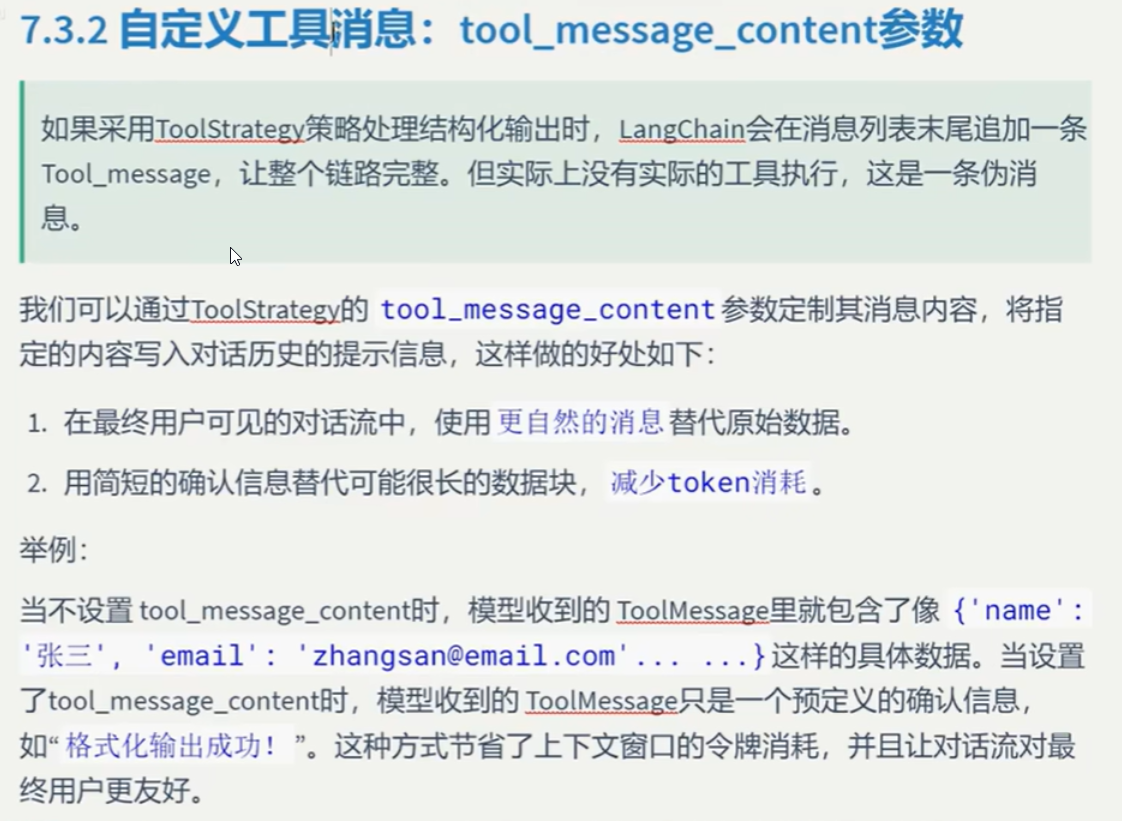
### 举例

In [5]:
from pydantic import BaseModel, Field
from langchain.agents.structured_output import AutoStrategy
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from rich import print as rprint
# 1.初始化模型
model = ChatOpenAI(
    model="carstenuhlig/omnicoder-9b:latest",
    # model="qwen3-vl:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)
# 2.使用Pydantic结构方式来定义一个类
class ContactInfo(BaseModel):
    """用户的联系方式"""
    name: str = Field(description="用户姓名")
    email: str = Field(description="用户邮箱")
    phone: str = Field(description="用户电话")

# 3.创建agent
agent = create_agent(
    model=model,
    tools=[],
    response_format=ToolStrategy(
        schema=ContactInfo,
        tool_message_content="格式化输出成功！！！"
    ), # 结构化输出的第3种方式

)
# 3.调用
result = agent.invoke({
    "messages":[{"role":"user","content":"请提取项目文本的用户信息：小李的email是 wxm1234@gmail.com,电话是13532677677"}]
})

rprint(result)

{
    'messages': [
        HumanMessage(
            content='请提取项目文本的用户信息：小李的email是 wxm1234@gmail.com,电话是13532677677',
            additional_kwargs={},
            response_metadata={},
            id='25e8eb64-8375-46de-a408-40c0fa37b489'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 127,
                    'prompt_tokens': 234,
                    'total_tokens': 361,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'carstenuhlig/omnicoder-9b:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-889',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a1141d-1e3f-7852-8fe6-9c8ed4f41630-0',
            tool_calls=[
                {
                    'name': 'ContactInfo',
                    'args': {'email': 'wxm1234@gmail.com', 'name': '小李', 'phone': '13532677677'},
                    'id': 'call_vhaswr6m',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 234,
                'output_tokens': 127,
                'total_tokens': 361,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='格式化输出成功！！！',
            name='ContactInfo',
            id='905bc998-ff05-40cd-8e3d-6debdbe5105b',
            tool_call_id='call_vhaswr6m'
        )
    ],
    'structured_response': ContactInfo(name='小李', email='wxm1234@gmail.com', phone='13532677677')
}